# UTS Pembelajaran Mesin — Klasifikasi Tingkat Obesitas
## Universitas Dian Nuswantoro | Semester Genap 2025/2026

| Info | Detail |
|------|--------|
| **Nama** | Anza Ali S |
| **NIM** | A11.2024.15791 |
| **Kelas** | A11.4401 / A11.4410 |
| **Dosen** | Junta Zeniarja, M.Kom |
| **Dataset** | Estimation of Obesity Levels — UCI ML Repository |
| **Target** | NObeyesdad (7 kelas multiclass) |

---

##  Peta Soal → Cell Notebook

| Soal | Topik | Cell |
|------|-------|------|
| **Soal 01** | Konsep Dasar ML & Problem Framing | Cell 1 (Instalasi) + Cell 3 (Import) + Markdown ini |
| **Soal 02** | Audit Dataset & Preprocessing | Cell 4 (Load & Audit) + Cell 5 (Preprocessing) |
| **Soal 03** | Seleksi Atribut, Split, Desain Eksperimen | Cell 6 |
| **Soal 04** | Implementasi & Perbandingan Algoritma | Cell 7 (Training) + Cell 8 (Visualisasi) |
| **Soal 05** | Analisis Hasil & Rekomendasi Model | Cell 9 (Feature Imp.) + Cell 10 (Error Analysis) |
| **Bonus** | Cross-Validation & Demo Inference | Cell 11 + Cell 12 |

---

##  Cara Menjalankan Notebook
1. Jalankan **Cell 1** → install library
2. Jalankan **Cell 2** → upload dataset CSV
3. Jalankan semua cell **secara berurutan** dari atas ke bawah
4. Hasil model & grafik tersimpan otomatis di folder `/content/models/` dan `/content/reports/`


---
#  SOAL 01 — Konsep Dasar Pembelajaran Mesin & Problem Framing
**Bobot: 20% | Sub-CPMK: A1164405-81.1**

> **Tujuan:** Menunjukkan pemahaman konsep dasar machine learning dan kemampuan membingkai masalah klasifikasi yang akan dikerjakan.

---

## 1.1 Pengertian Pembelajaran Mesin

**Pembelajaran mesin (Machine Learning)** adalah cabang kecerdasan buatan yang memungkinkan komputer belajar dari data tanpa diprogram secara eksplisit. Sistem ML mengidentifikasi pola dalam data dan membangun model prediktif berdasarkan pola tersebut.

### Perbedaan Supervised, Unsupervised, dan Semi-Supervised Learning

| Aspek | Supervised | Unsupervised | Semi-Supervised |
|-------|-----------|--------------|-----------------|
| **Label data** | Semua data berlabel | Tidak ada label | Sebagian berlabel |
| **Tujuan** | Prediksi label baru | Temukan pola tersembunyi | Manfaatkan data tidak berlabel |
| **Contoh algoritma** | KNN, Decision Tree, SVM | K-Means, DBSCAN | LabelPropagation |
| **Contoh kasus** | Klasifikasi email spam | Segmentasi pelanggan | Klasifikasi teks medis |
| **Kebutuhan data** | Data berlabel banyak | Data tidak perlu label | Sedikit label, banyak unlabeled |

>  **Proyek ini** menggunakan **supervised learning** untuk masalah klasifikasi, dengan tambahan eksplorasi **semi-supervised** (LabelPropagation & LabelSpreading) sebagai perbandingan.

---

## 1.2 Mengapa Ini Masalah Klasifikasi?

Kasus yang dipilih — **prediksi tingkat obesitas** — adalah masalah **klasifikasi multiclass** karena:

1. **Target bersifat diskret & berkategori**: NObeyesdad memiliki 7 kelas yang terdefinisi jelas (Insufficient_Weight, Normal_Weight, Overweight I/II, Obesity I/II/III)
2. **Bukan regresi**: Target bukan nilai kontinu seperti berat badan (kg), melainkan kategori klinis
3. **Bukan klustering**: Label kelas sudah tersedia di dataset (ground truth ada), sehingga tidak perlu mencari kluster secara tak berarah

---

## 1.3 Identifikasi Fitur, Target, dan Potensi Tantangan

**Dataset:** Estimation of Obesity Levels — 2.111 sampel, 17 kolom

| Atribut | Tipe Data | Keterangan | Potensi Tantangan |
|---------|-----------|------------|-------------------|
| Gender | Kategorikal (biner) | Jenis kelamin | Binary encoding |
| Age | Numerik kontinu | Usia | Outlier mungkin ada |
| Height | Numerik kontinu | Tinggi badan (meter) | — |
| Weight | Numerik kontinu | Berat badan (kg) | Outlier mungkin ada |
| family_history_with_overweight | Kategorikal (biner) | Riwayat keluarga | Binary encoding |
| FAVC | Kategorikal (biner) | Konsumsi makanan berkalori | Binary encoding |
| FCVC | Numerik | Frekuensi konsumsi sayur | — |
| NCP | Numerik | Jumlah makan besar per hari | Outlier |
| CAEC | Kategorikal ordinal | Makan di luar waktu makan | Ordinal encoding |
| SMOKE | Kategorikal (biner) | Merokok | Binary encoding |
| CH2O | Numerik | Konsumsi air harian | — |
| SCC | Kategorikal (biner) | Monitoring kalori | Binary encoding |
| FAF | Numerik | Frekuensi aktivitas fisik | Outlier |
| TUE | Numerik | Waktu penggunaan teknologi | — |
| CALC | Kategorikal ordinal | Konsumsi alkohol | Ordinal encoding |
| MTRANS | Kategorikal nominal | Transportasi utama | One-hot encoding |
| **NObeyesdad** | **Kategorikal (7 kelas)** | **TARGET** | **Multiclass** |

**Potensi tantangan utama:**
- Banyak fitur kategorikal → perlu strategi encoding berbeda (binary, ordinal, one-hot)
- Distribusi kelas perlu diperiksa → potensi imbalance class
- Outlier pada fitur numerik (berat, usia) → perlu winsorizing


---
##  Cell 1 — Install Library
> **Soal 01 | Setup Lingkungan**
>
> Menginstal library tambahan yang tidak tersedia secara default di Google Colab.
> Jalankan cell ini **pertama kali** sebelum cell lainnya.
>
> | Library | Fungsi |
> |---------|--------|
> | `lightgbm` | Gradient boosting berbasis histogram  |
> | `xgboost` | Gradient boosting populer |
> | `imbalanced-learn` | Tools untuk menangani dataset tidak seimbang |


In [20]:
# ── Install library tambahan ──────────────────────────
!pip install lightgbm xgboost imbalanced-learn -q

import warnings
warnings.filterwarnings("ignore")

# Verifikasi versi
import sklearn, lightgbm, xgboost
print(f"scikit-learn : {sklearn.__version__}")
print(f"LightGBM     : {lightgbm.__version__}")
print(f"XGBoost      : {xgboost.__version__}")
print("✓ Semua library siap!")


scikit-learn : 1.6.1
LightGBM     : 4.6.0
XGBoost      : 3.2.0
✓ Semua library siap!


---
##  Cell 2 — Upload Dataset
> **Soal 02 | Persiapan Data**
>
> Upload file dataset CSV dari komputer lokal ke Google Colab.
>
> **File yang dibutuhkan:** `ObesityDataSet_raw_and_data_sinthetic.csv`
> **Sumber:** [UCI ML Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)
>
>  **Catatan:** Jika mengupload file ZIP dari project ini, akan diekstrak otomatis.


In [21]:
from google.colab import files
import os, zipfile

# Upload file
print("Silakan upload file: ObesityDataSet_raw_and_data_sinthetic.csv")
print("(atau file ZIP dari project ini)")
uploaded = files.upload()

# Jika upload ZIP, ekstrak dulu
for fname in uploaded.keys():
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall("/content/")
        print(f"✓ ZIP diekstrak")

# Setup folder output
os.makedirs("/content/data",    exist_ok=True)
os.makedirs("/content/models",  exist_ok=True)
os.makedirs("/content/reports", exist_ok=True)
print("✓ Folder data/, models/, reports/ siap")


Silakan upload file: ObesityDataSet_raw_and_data_sinthetic.csv
(atau file ZIP dari project ini)


Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic (1).csv
✓ Folder data/, models/, reports/ siap


---
##  Cell 3 — Import Semua Library & Konstanta Global
> **Soal 01 | Setup**
>
> Mengimpor seluruh library yang akan digunakan sepanjang notebook.
>
> | Kategori | Library |
> |----------|---------|
> | Manipulasi data | `pandas`, `numpy` |
> | Visualisasi | `matplotlib`, `seaborn` |
> | Model wajib UTS | KNN, Naive Bayes, Decision Tree |
> | Model tambahan | Extra Trees, Random Forest, Logistic Regression, SVM, LightGBM, XGBoost |
> | Model semi-supervised | LabelPropagation, LabelSpreading |
> | Preprocessing | LabelEncoder, StandardScaler, OrdinalEncoder |
> | Evaluasi | accuracy, precision, recall, F1, confusion matrix |
>
> **Konstanta global:**
> - `RANDOM_SEED = 42` → reprodusibilitas eksperimen
> - `ORDER_TARGET` → urutan kelas dari kurus hingga obesitas ekstrem
> - `SHORT` → label singkat untuk visualisasi confusion matrix


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, joblib, warnings
warnings.filterwarnings("ignore")

# ── Model Klasifikasi ─────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier          # KNN
from sklearn.naive_bayes import GaussianNB                  # Naive Bayes
from sklearn.tree import DecisionTreeClassifier             # Decision Tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.semi_supervised import LabelPropagation, LabelSpreading

# ── Preprocessing ─────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

# ── Evaluasi & Utilitas ───────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ── Konstanta Global ──────────────────────────────────
RANDOM_SEED  = 42          # Seed untuk reprodusibilitas
UNLABELED    = -1          # Label untuk semi-supervised learning

# Urutan kelas target dari ringan ke berat
ORDER_TARGET = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I",  "Overweight_Level_II",
    "Obesity_Type_I",      "Obesity_Type_II", "Obesity_Type_III"
]
# Label singkat untuk visualisasi
SHORT = ["Insuf.","Normal","OW-I","OW-II","Ob-I","Ob-II","Ob-III"]

print("✓ Semua import berhasil!")
print(f"  Random Seed : {RANDOM_SEED}")
print(f"  Kelas target: {len(ORDER_TARGET)} kelas")
print(f"  {ORDER_TARGET}")


✓ Semua import berhasil!
  Random Seed : 42
  Kelas target: 7 kelas
  ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']


---
#  SOAL 02 — Audit Dataset & Data Preprocessing
**Bobot: 20% | Sub-CPMK: A1164405-101.1**

> **Tujuan:** Menganalisis kebutuhan atribut dataset dan merancang preprocessing yang tepat.

**Dataset yang digunakan:**
- **Nama:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition
- **Sumber:** UCI ML Repository (https://archive.ics.uci.edu/dataset/544)
- **Ukuran:** 2.111 baris × 17 kolom
- **Target:** NObeyesdad (7 kelas multiclass)
- **Alasan pemilihan:** Dataset ini relevan dengan masalah kesehatan nyata, memiliki campuran fitur numerik dan kategorikal yang kaya, serta cukup seimbang antar kelas sehingga ideal untuk membandingkan algoritma klasifikasi.


## Cell 4 — Load Dataset & Audit Data
> **Soal 02 | Langkah 1-2: Pemilihan Dataset & Audit**
>
> Memuat dataset ke memory dan melakukan **audit awal** sebelum preprocessing.
>
> **Audit yang dilakukan:**
> - Dimensi data (baris × kolom)
> - Missing value per kolom
> - Jumlah data duplikat
> - Tipe data setiap kolom
> - Distribusi kelas target
>
> **Visualisasi:**
> - Distribusi kelas target → cek imbalance
> - Histogram Age & Weight → cek distribusi
> - Boxplot Weight per kelas → cek outlier
> - Heatmap korelasi → cek multikolinearitas
> - Crosstab Gender vs Kelas → cek pola gender


 Menggunakan file: /content/ObesityDataSet_raw_and_data_sinthetic (1).csv
AUDIT DATA — SEBELUM PREPROCESSING

  Dimensi    : 2111 baris x 17 kolom
  Missing    : 0 total
  Duplikat   : 24 baris

  Tipe data per kolom:
    Gender                                  : object     | unique=2
    Age                                     : float64    | unique=1402
    Height                                  : float64    | unique=1574
    Weight                                  : float64    | unique=1525
    family_history_with_overweight          : object     | unique=2
    FAVC                                    : object     | unique=2
    FCVC                                    : float64    | unique=810
    NCP                                     : float64    | unique=635
    CAEC                                    : object     | unique=4
    SMOKE                                   : object     | unique=2
    CH2O                                    : float64    | unique=1268
    SCC           

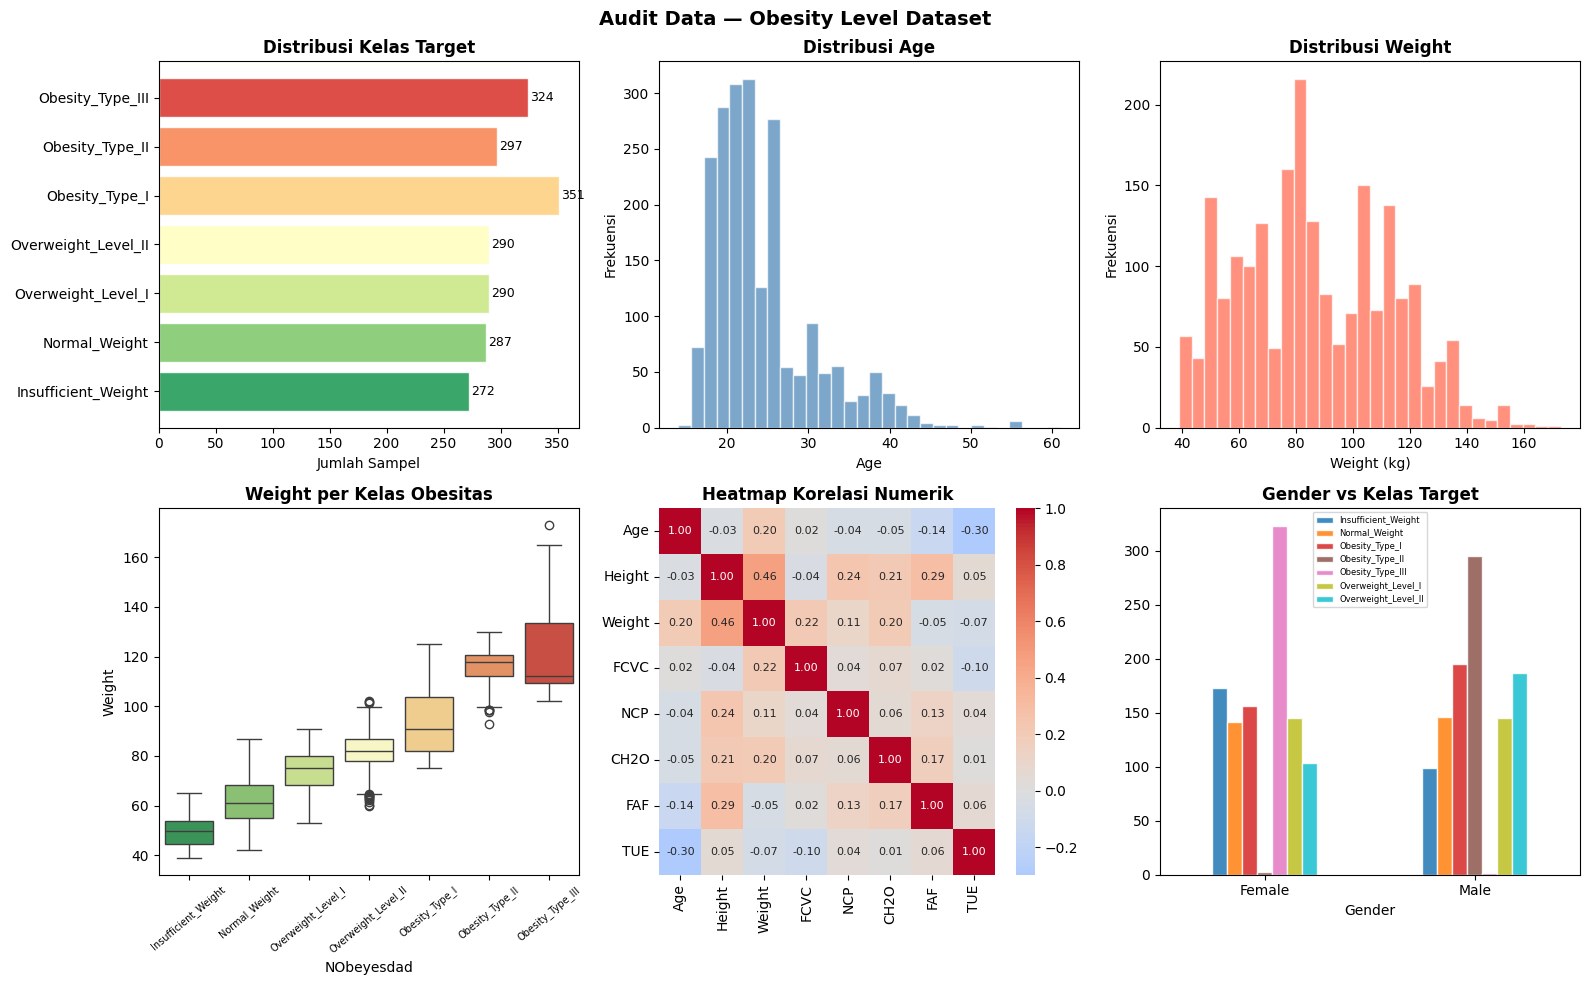

✓ Audit selesai! Grafik disimpan ke reports/audit_data.png


In [23]:
# ── Load Dataset ──────────────────────────────────────
import glob

csv_files = glob.glob("/content/**/*.csv", recursive=True)
csv_files += glob.glob("/content/*.csv")
obesity_files = [f for f in csv_files if "obesity" in f.lower() or "Obesity" in f]

if obesity_files:
    DATA_PATH = obesity_files[0]
else:
    DATA_PATH = "/content/ObesityDataSet_raw_and_data_sinthetic.csv"

print(f" Menggunakan file: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH)

# ── Audit Data ────────────────────────────────────────
print("="*65)
print("AUDIT DATA — SEBELUM PREPROCESSING")
print("="*65)
print(f"\n  Dimensi    : {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
print(f"  Missing    : {df_raw.isnull().sum().sum()} total")
print(f"  Duplikat   : {df_raw.duplicated().sum()} baris")

print("\n  Tipe data per kolom:")
for col in df_raw.columns:
    print(f"    {col:40s}: {str(df_raw[col].dtype):10s} | unique={df_raw[col].nunique()}")

print(f"\n  Distribusi kelas target (NObeyesdad):")
for k, v in df_raw["NObeyesdad"].value_counts().reindex(ORDER_TARGET).items():
    bar = "█" * int(v/15)
    print(f"    {k:30s}: {v:4d} ({v/len(df_raw)*100:.1f}%)  {bar}")

# ── Statistik Deskriptif ──────────────────────────────
print("\n  Statistik deskriptif fitur numerik:")
print(df_raw.describe().round(2).to_string())

# ── Visualisasi Audit ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Audit Data — Obesity Level Dataset", fontsize=14, fontweight="bold")

# Plot 1: Distribusi kelas target
vc = df_raw["NObeyesdad"].value_counts().reindex(ORDER_TARGET)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 7))
axes[0,0].barh(ORDER_TARGET, vc.values, color=colors, alpha=0.85, edgecolor="white")
axes[0,0].set_title("Distribusi Kelas Target", fontweight="bold")
axes[0,0].set_xlabel("Jumlah Sampel")
for i, v in enumerate(vc.values):
    axes[0,0].text(v+2, i, str(v), va="center", fontsize=9)

# Plot 2: Histogram Age
axes[0,1].hist(df_raw["Age"], bins=30, color="steelblue", alpha=0.7, edgecolor="white")
axes[0,1].set_title("Distribusi Age", fontweight="bold")
axes[0,1].set_xlabel("Age"); axes[0,1].set_ylabel("Frekuensi")

# Plot 3: Histogram Weight
axes[0,2].hist(df_raw["Weight"], bins=30, color="tomato", alpha=0.7, edgecolor="white")
axes[0,2].set_title("Distribusi Weight", fontweight="bold")
axes[0,2].set_xlabel("Weight (kg)"); axes[0,2].set_ylabel("Frekuensi")

# Plot 4: Boxplot Weight per kelas
sns.boxplot(data=df_raw, x="NObeyesdad", y="Weight", ax=axes[1,0],
            palette="RdYlGn_r", order=ORDER_TARGET)
axes[1,0].set_title("Weight per Kelas Obesitas", fontweight="bold")
axes[1,0].tick_params(axis="x", rotation=40, labelsize=7)

# Plot 5: Heatmap korelasi numerik
num_cols = ["Age","Height","Weight","FCVC","NCP","CH2O","FAF","TUE"]
corr_df = df_raw[num_cols].corr()
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1,1], annot_kws={"size":8})
axes[1,1].set_title("Heatmap Korelasi Numerik", fontweight="bold")

# Plot 6: Gender vs Kelas target
ct = pd.crosstab(df_raw["Gender"], df_raw["NObeyesdad"])
ct.plot(kind="bar", ax=axes[1,2], colormap="tab10", alpha=0.85, edgecolor="white")
axes[1,2].set_title("Gender vs Kelas Target", fontweight="bold")
axes[1,2].tick_params(axis="x", rotation=0)
axes[1,2].legend(fontsize=6)

plt.tight_layout()
plt.savefig("/content/reports/audit_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Audit selesai! Grafik disimpan ke reports/audit_data.png")


## Cell 5 — Data Preprocessing
> **Soal 02 | Langkah 3-5: Pipeline Preprocessing**
>
> Mentransformasi data mentah menjadi format numerik yang siap digunakan oleh algoritma machine learning.
>
> **Pipeline 6 Langkah:**
>
> | Langkah | Teknik | Kolom | Alasan |
> |---------|--------|-------|--------|
> | 1 | Hapus duplikat | Semua | Mencegah bias pada training |
> | 2 | Binary encoding | Gender, family_history, FAVC, SMOKE, SCC | 2 nilai → 0/1, efisien |
> | 3 | Ordinal encoding | CAEC, CALC | Ada urutan: no < Sometimes < Frequently < Always |
> | 4 | One-hot encoding | MTRANS | Nominal, tidak ada urutan, 5 kategori |
> | 5 | Winsorizing outlier | Age, Height, Weight, dll. | Clip nilai ekstrem tanpa kehilangan data |
> | 6 | Encoding target | NObeyesdad → 0–6 | Diperlukan algoritma sklearn |
>
> **Mengapa winsorizing dan bukan hapus outlier?**
> Menghapus outlier mengurangi jumlah data. Winsorizing (clip ke batas IQR) mempertahankan semua sampel namun mengurangi pengaruh nilai ekstrem.


In [24]:
import joblib
import pandas as pd

# ── Preprocessing Pipeline ────────────────────────────
df = df_raw.copy()
n_awal = len(df)

# ── Langkah 1: Hapus duplikat ─────────────────────────
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"[1] Hapus duplikat: {n_dup} baris dihapus → {len(df)} baris tersisa")

# ── Langkah 2: Binary encoding ────────────────────────
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})
for col in ["family_history_with_overweight","FAVC","SMOKE","SCC"]:
    df[col] = df[col].map({"yes":1, "no":0})
print("[2] Binary encoding: Gender, family_history_with_overweight, FAVC, SMOKE, SCC")

# ── Langkah 3: Ordinal encoding ───────────────────────
# CAEC & CALC: no=0, Sometimes=1, Frequently=2, Always=3
ORDER_ORD = [["no","Sometimes","Frequently","Always"]] * 2
oe = OrdinalEncoder(categories=ORDER_ORD)
df[["CAEC","CALC"]] = oe.fit_transform(df[["CAEC","CALC"]])
print("[3] Ordinal encoding: CAEC & CALC → no=0, Sometimes=1, Frequently=2, Always=3")

# ── Langkah 4: One-hot encoding ───────────────────────
df = pd.get_dummies(df, columns=["MTRANS"], prefix="MTRANS", drop_first=False)
mtrans_cols = [c for c in df.columns if c.startswith("MTRANS_")]
df[mtrans_cols] = df[mtrans_cols].astype(int)
print(f"[4] One-hot MTRANS → {len(mtrans_cols)} kolom baru: {mtrans_cols}")

# ── Langkah 5: Winsorizing outlier ────────────────────
NUM_COLS = ["Age","Height","Weight","FCVC","NCP","CH2O","FAF","TUE"]
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_clip = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
print(f"[5] Winsorizing outlier pada: {NUM_COLS}")

# ── Langkah 6: Encoding target ────────────────────────
tmap = {v:i for i,v in enumerate(ORDER_TARGET)}
df["target"] = df["NObeyesdad"].map(tmap)
df = df.drop(columns=["NObeyesdad"])
print("[6] Encoding target: Insufficient_Weight=0 … Obesity_Type_III=6")

# ── Simpan encoder & siapkan X, y ────────────────────
scaler = StandardScaler()
joblib.dump(oe, "/content/models/ordinal_encoder.joblib")
print("✓ OrdinalEncoder disimpan ke models/ordinal_encoder.joblib")

X = df.drop(columns=["target"]).astype(float)
y = df["target"].astype(int)

# ── Tabel Before/After Preprocessing ─────────────────
print("\n" + "="*60)
print("TABEL RINGKASAN BEFORE / AFTER PREPROCESSING")
print("="*60)
summary = pd.DataFrame({
    "Aspek":   ["Jumlah Baris","Jumlah Kolom (Fitur)","Missing Value","Duplikat",
                 "Encoding Target","Skala Fitur","Kolom MTRANS"],
    "Sebelum": [2111, 16, "0 (dataset bersih)", n_dup,
                 "String (7 label)","Heterogen (mix)","1 kolom kategorikal"],
    "Sesudah": [len(df), X.shape[1], 0, 0,
                 "Integer 0–6","Akan di-StandardScaler","5 kolom one-hot"]
})
print(summary.to_string(index=False))

print(f"\n  Shape akhir: X={X.shape}, y={y.shape}")
print(f"  Fitur: {X.columns.tolist()}")

# Simpan data bersih
CLEAN_DATA_PATH = "/content/data/obesity_cleaned_data.csv"
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"\n✓ Data bersih disimpan ke: {CLEAN_DATA_PATH}")
print("✓ Preprocessing selesai!")


[1] Hapus duplikat: 24 baris dihapus → 2087 baris tersisa
[2] Binary encoding: Gender, family_history_with_overweight, FAVC, SMOKE, SCC
[3] Ordinal encoding: CAEC & CALC → no=0, Sometimes=1, Frequently=2, Always=3
[4] One-hot MTRANS → 5 kolom baru: ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']
[5] Winsorizing outlier pada: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
[6] Encoding target: Insufficient_Weight=0 … Obesity_Type_III=6
✓ OrdinalEncoder disimpan ke models/ordinal_encoder.joblib

TABEL RINGKASAN BEFORE / AFTER PREPROCESSING
               Aspek             Sebelum                Sesudah
        Jumlah Baris                2111                   2087
Jumlah Kolom (Fitur)                  16                     20
       Missing Value  0 (dataset bersih)                      0
            Duplikat                  24                      0
     Encoding Target    String (7 label)            Integer 

---
# SOAL 03 — Seleksi Atribut, Split Data, dan Desain Eksperimen
**Bobot: 20% | Sub-CPMK: A1164405-101.1**

> **Tujuan:** Memilih atribut dan algoritma yang tepat serta menyusun rancangan eksperimen yang valid.

## 3.1 Fitur Akhir untuk Pemodelan

Semua **20 fitur** digunakan setelah preprocessing (tidak ada yang dibuang), karena:
- Setiap fitur memiliki landasan ilmiah terhadap prediksi obesitas
- Tidak ada fitur dengan korelasi sangat tinggi (>0.9) yang menyebabkan multikolinearitas fatal
- MTRANS diperluas menjadi 5 kolom one-hot yang masing-masing informatif

## 3.2 Kesesuaian Algoritma dengan Dataset

| Algoritma | Kesesuaian | Alasan |
|-----------|-----------|--------|
| **KNN** | ✓ Sesuai | Dataset sudah di-scale → jarak Euclidean valid |
| **Decision Tree** | ✓ Sesuai | Mix numerik+kategorikal, bisa interpretasi visual |
| **Naive Bayes** | ⚠ Terbatas | Asumsi independensi fitur mungkin tidak terpenuhi |
| **Extra Trees** | ✓ Sangat Sesuai | Lebih cepat dari RF, robust terhadap noise |
| **Random Forest** | ✓ Sangat Sesuai | Ensemble, robust, akurasi tinggi |
| **LightGBM/XGBoost** | ✓ Sangat Sesuai | Gradient boosting, terbaik untuk tabular data |
| **LabelPropagation** | ✓ Eksploratif | Simulasi skenario data medis dengan label parsial |


## Cell 6 — Split Data & Rancangan Eksperimen
> **Soal 03 | Langkah 2-5: Strategi Splitting & Tabel Eksperimen**
>
> **Strategi splitting:**
> - **80% train : 20% test** dengan `stratify=y` → proporsi kelas sama di train & test
> - `random_state=42` → reprodusibilitas
> - Scaler hanya di-**fit** pada train (mencegah data leakage!)
>
> **Data semi-supervised:**
> - 30% sampel training di-*unlabel* (label → -1) untuk LabelPropagation & LabelSpreading
>
> **Kriteria model terbaik:** F1-macro (bobot sama untuk semua 7 kelas)


In [25]:
# ── Split Data 80:20 Stratified ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# StandardScaler: fit HANYA pada train → hindari data leakage
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns
)

# Simpan scaler yang sudah di-fit
joblib.dump(scaler, "/content/models/scaler.joblib")
print("✓ StandardScaler disimpan ke models/scaler.joblib")

print("="*60)
print("SPLIT DATA")
print("="*60)
print(f"  Strategi   : Train-Test Split 80:20 + Stratified")
print(f"  Seed       : {RANDOM_SEED}")
print(f"  X_train    : {X_train_sc.shape}  (80%)")
print(f"  X_test     : {X_test_sc.shape}   (20%)")
print(f"  y_train distribusi: {y_train.value_counts().sort_index().to_dict()}")
print(f"  y_test  distribusi: {y_test.value_counts().sort_index().to_dict()}")

# ── Data Semi-supervised ──────────────────────────────
np.random.seed(RANDOM_SEED)
y_semi = y_train.values.copy()
idx_ul = np.random.choice(len(y_semi), int(len(y_semi)*0.30), replace=False)
y_semi[idx_ul] = UNLABELED
print(f"\n  Semi-supervised: {(y_semi!=-1).sum()} berlabel | {(y_semi==-1).sum()} tidak berlabel (30%)")

# ── Tabel Rancangan Eksperimen ───────────────────────
print("\n" + "="*70)
print("TABEL RANCANGAN EKSPERIMEN")
print("="*70)
exp = pd.DataFrame({
    "No": range(1, 13),
    "Model": ["Baseline (Dummy)","KNN","Naive Bayes","Decision Tree",
               "Extra Trees","Random Forest","Logistic Reg.",
               "SVM","LightGBM","XGBoost",
               "LabelPropagation","LabelSpreading"],
    "Tipe":  ["Referensi"]+["Supervised"]*9+["Semi-supervised"]*2,
    "Parameter Utama": [
        "strategy=most_frequent",
        "k=7, metric=euclidean",
        "GaussianNB (default)",
        "max_depth=10, gini, seed=42",
        "n=100, seed=42, n_jobs=-1",
        "n=100, seed=42, n_jobs=-1",
        "C=1.0, lbfgs, max_iter=2000",
        "kernel=rbf, C=1.0, gamma=scale",
        "n=200, lr=0.05, leaves=31",
        "n=200, lr=0.05, depth=6",
        "kernel=rbf, gamma=20, 30% unlabeled",
        "kernel=rbf, alpha=0.2, 30% unlabeled",
    ],
    "Hipotesis F1-macro": [
        "~0.04 (acak)",">0.80","~0.45",">0.90",
        ">0.92",">0.93",">0.85",">0.90",
        ">0.96",">0.95","~0.80","~0.82"
    ]
})
print(exp.to_string(index=False))
print()
print("  KRITERIA MODEL TERBAIK:")
print("  → F1-macro tertinggi (semua 7 kelas mendapat bobot sama)")
print("  → Digunakan pada Soal 04 dan Soal 05")
print("\n✓ Setup eksperimen selesai!")


✓ StandardScaler disimpan ke models/scaler.joblib
SPLIT DATA
  Strategi   : Train-Test Split 80:20 + Stratified
  Seed       : 42
  X_train    : (1669, 20)  (80%)
  X_test     : (418, 20)   (20%)
  y_train distribusi: {0: 214, 1: 225, 2: 221, 3: 232, 4: 281, 5: 237, 6: 259}
  y_test  distribusi: {0: 53, 1: 57, 2: 55, 3: 58, 4: 70, 5: 60, 6: 65}

  Semi-supervised: 1169 berlabel | 500 tidak berlabel (30%)

TABEL RANCANGAN EKSPERIMEN
 No            Model            Tipe                      Parameter Utama Hipotesis F1-macro
  1 Baseline (Dummy)       Referensi               strategy=most_frequent       ~0.04 (acak)
  2              KNN      Supervised                k=7, metric=euclidean              >0.80
  3      Naive Bayes      Supervised                 GaussianNB (default)              ~0.45
  4    Decision Tree      Supervised          max_depth=10, gini, seed=42              >0.90
  5      Extra Trees      Supervised            n=100, seed=42, n_jobs=-1              >0.92
  6   

---
#  SOAL 04 — Implementasi dan Perbandingan Algoritma Klasifikasi
**Bobot: 20% | Sub-CPMK: A1164405-81.2**

> **Tujuan:** Mengimplementasikan dan membandingkan karakteristik algoritma klasifikasi berdasarkan hasil eksperimen.

**11 model dilatih** → Wajib UTS (KNN, Decision Tree, Naive Bayes) + Tambahan (Extra Trees, RF, LR, SVM, LightGBM, XGBoost, LabelPropagation, LabelSpreading)


## Cell 7 — Training 11 Model Klasifikasi
> **Soal 04 | Langkah 1-3: Latih Model & Evaluasi Metrik**
>
>  **Perkiraan waktu:** LightGBM ~1-2 menit, LabelPropagation ~30 detik. Harap tunggu.
>
> **Metrik yang dihitung untuk setiap model:**
> - **Accuracy** → persentase prediksi benar keseluruhan
> - **Precision** (weighted) → presisi rata-rata berbobot jumlah sampel
> - **Recall** (weighted) → recall rata-rata berbobot jumlah sampel
> - **F1 weighted** → harmonic mean precision-recall, berbobot kelas
> - **F1 macro** → harmonic mean precision-recall, **bobot sama semua kelas** ← *kriteria utama*
> - **Waktu training (ms)** → efisiensi komputasi
>
> Semua model disimpan ke `/content/models/` menggunakan `joblib`.


In [26]:
# ── Definisi Semua Model ─────────────────────────────
SEMISUP = {"LabelPropagation", "LabelSpreading"}

model_defs = [
    # ── 3 Model Wajib UTS ────────────────────────────
    ("KNN",
     KNeighborsClassifier(n_neighbors=7, metric="euclidean"),
     "Supervised"),
    ("Naive Bayes",
     GaussianNB(),
     "Supervised"),
    ("Decision Tree",
     DecisionTreeClassifier(max_depth=10, criterion="gini", random_state=RANDOM_SEED),
     "Supervised"),
    # ── Model Tambahan ────────────────────────────────
    ("Extra Trees",
     ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
     "Supervised"),
    ("Random Forest",
     RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
     "Supervised"),
    ("Logistic Regression",
     LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs", random_state=RANDOM_SEED),
     "Supervised"),
    ("SVM",
     SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_SEED),
     "Supervised"),
    ("LightGBM",
     LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
     "Supervised"),
    ("XGBoost",
     XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                   random_state=RANDOM_SEED, n_jobs=-1, verbosity=0),
     "Supervised"),
    # ── Model Semi-supervised ─────────────────────────
    ("LabelPropagation",
     LabelPropagation(kernel="rbf", gamma=20, max_iter=1000),
     "Semi-sup"),
    ("LabelSpreading",
     LabelSpreading(kernel="rbf", alpha=0.2, max_iter=1000),
     "Semi-sup"),
]

# ── Baseline Dummy ────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train_sc, y_train)
yp_dummy = dummy.predict(X_test_sc)
f1m_dummy = f1_score(y_test, yp_dummy, average="macro", zero_division=0)
print(f"  Baseline (Dummy): F1-macro={f1m_dummy:.4f}  Acc={accuracy_score(y_test, yp_dummy):.4f}")
print()

# ── Training Loop ─────────────────────────────────────
rows, preds, fitted = [], {}, {}
print("Memulai training semua model...")
print("-"*75)

for nama, model, tipe in model_defs:
    # Model semi-supervised menggunakan data dengan 30% unlabeled
    yf  = y_semi if nama in SEMISUP else y_train.values
    Xtr = X_train_sc.values
    Xte = X_test_sc.values

    t0 = time.time()
    model.fit(Xtr, yf)
    t_tr = (time.time()-t0)*1000

    yp   = model.predict(Xte)
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, average="weighted", zero_division=0)
    rec  = recall_score(y_test, yp, average="weighted", zero_division=0)
    f1w  = f1_score(y_test, yp, average="weighted", zero_division=0)
    f1m  = f1_score(y_test, yp, average="macro", zero_division=0)

    preds[nama]  = yp
    fitted[nama] = model
    rows.append({"Model":nama, "Tipe":tipe,
                 "Accuracy":round(acc,4), "Precision":round(prec,4),
                 "Recall":round(rec,4), "F1_weighted":round(f1w,4),
                 "F1_macro":round(f1m,4), "Train_ms":round(t_tr,1)})

    # Simpan model ke file
    fname = nama.lower().replace(" ","_")
    joblib.dump(model, f"/content/models/{fname}.joblib")
    print(f"  ✓ {nama:25s} [{tipe:10s}]: Acc={acc:.4f}  F1m={f1m:.4f}  ({t_tr:.0f}ms)")

# ── Tabel Komparatif Lengkap ──────────────────────────
df_hasil = pd.DataFrame(rows)

print("\n" + "="*75)
print("TABEL KOMPARATIF LENGKAP SEMUA MODEL")
print("="*75)
print(df_hasil.to_string(index=False))

# ── Simpan model terbaik ──────────────────────────────
best_name = df_hasil.set_index("Model")["F1_macro"].idxmax()
best_row  = df_hasil[df_hasil["Model"]==best_name].iloc[0]
joblib.dump(fitted[best_name], "/content/models/best_model.joblib")

print(f"\n MODEL TERBAIK: {best_name}")
print(f"   F1-macro = {best_row['F1_macro']}  |  Accuracy = {best_row['Accuracy']}")
print("\n✓ Semua model tersimpan di /content/models/")


  Baseline (Dummy): F1-macro=0.0410  Acc=0.1675

Memulai training semua model...
---------------------------------------------------------------------------
  ✓ KNN                       [Supervised]: Acc=0.8062  F1m=0.7942  (7ms)
  ✓ Naive Bayes               [Supervised]: Acc=0.5287  F1m=0.4305  (8ms)
  ✓ Decision Tree             [Supervised]: Acc=0.9211  F1m=0.9178  (30ms)
  ✓ Extra Trees               [Supervised]: Acc=0.9330  F1m=0.9311  (650ms)
  ✓ Random Forest             [Supervised]: Acc=0.9426  F1m=0.9407  (782ms)
  ✓ Logistic Regression       [Supervised]: Acc=0.8660  F1m=0.8611  (196ms)
  ✓ SVM                       [Supervised]: Acc=0.8565  F1m=0.8520  (998ms)
  ✓ LightGBM                  [Supervised]: Acc=0.9641  F1m=0.9637  (11518ms)
  ✓ XGBoost                   [Supervised]: Acc=0.9617  F1m=0.9617  (6802ms)
  ✓ LabelPropagation          [Semi-sup  ]: Acc=0.8134  F1m=0.8016  (12704ms)
  ✓ LabelSpreading            [Semi-sup  ]: Acc=0.8062  F1m=0.7946  (372ms)

TABEL 

## Cell 7b — Classification Report 3 Model Wajib UTS
> **Soal 04 | Langkah 3: Detail Evaluasi Per Kelas**
>
> Menampilkan classification report lengkap untuk **KNN, Decision Tree, dan Naive Bayes** yang merupakan algoritma wajib sesuai soal UTS.
>
> Classification report menampilkan **precision, recall, dan F1-score per kelas** sehingga kita dapat melihat kelas mana yang paling sulit diprediksi oleh masing-masing algoritma.


In [27]:
print("=" * 65)
print("CLASSIFICATION REPORT — 3 MODEL WAJIB UTS")
print("=" * 65)

for nama in ["KNN", "Decision Tree", "Naive Bayes"]:
    yp = preds[nama]
    r  = df_hasil[df_hasil["Model"]==nama].iloc[0]
    print(f"\n{'─'*65}")
    print(f"  {nama} | Acc={r['Accuracy']:.4f} | F1-macro={r['F1_macro']:.4f} | Train={r['Train_ms']:.0f}ms")
    print(f"{'─'*65}")
    print(classification_report(y_test, yp, target_names=ORDER_TARGET, zero_division=0))

print("\n" + "─"*65)
print("KEKUATAN DAN KELEMAHAN:")
print("─"*65)
analisis = [
    ("KNN",
     "Sederhana, tidak ada asumsi distribusi, performa baik di data terstruktur",
     "Lambat saat prediksi (menghitung jarak semua training), sensitif terhadap noise",
     "Medium", "Rendah — black box berbasis kedekatan jarak"),
    ("Decision Tree",
     "Sangat interpretable (aturan if-then), cepat training & prediksi",
     "Overfitting jika depth tidak dibatasi, tidak stabil (sensitif perubahan data)",
     "Rendah", "Tinggi — dapat divisualisasi sebagai pohon keputusan"),
    ("Naive Bayes",
     "Sangat cepat, efisien memori, bekerja baik di data sedikit",
     "Asumsi independensi fitur sering dilanggar, akurasi lebih rendah",
     "Sangat Rendah", "Tinggi — probabilitas tiap kelas bisa dihitung eksplisit"),
]
for nama, kuat, lemah, komp, interp in analisis:
    r = df_hasil[df_hasil["Model"]==nama].iloc[0]
    print(f"\n  [{nama}] F1-macro={r['F1_macro']:.4f}")
    print(f"   Kekuatan       : {kuat}")
    print(f"   Kelemahan      : {lemah}")
    print(f"   Kompleksitas   : {komp}")
    print(f"   Interpretabilitas: {interp}")


CLASSIFICATION REPORT — 3 MODEL WAJIB UTS

─────────────────────────────────────────────────────────────────
  KNN | Acc=0.8062 | F1-macro=0.7942 | Train=7ms
─────────────────────────────────────────────────────────────────
                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.94      0.84        53
      Normal_Weight       0.67      0.49      0.57        57
 Overweight_Level_I       0.71      0.71      0.71        55
Overweight_Level_II       0.79      0.66      0.72        58
     Obesity_Type_I       0.78      0.89      0.83        70
    Obesity_Type_II       0.90      0.93      0.92        60
   Obesity_Type_III       0.97      0.98      0.98        65

           accuracy                           0.81       418
          macro avg       0.80      0.80      0.79       418
       weighted avg       0.80      0.81      0.80       418


─────────────────────────────────────────────────────────────────
  Decision Tree | Acc=0.9211 | F1-m

## Cell 8 — Visualisasi Komparatif Semua Model
> **Soal 04 | Langkah 4: Tabel dan Visualisasi Perbandingan**
>
> Membuat 3 visualisasi komprehensif:
>
> 1. **Confusion Matrix 3×4** — confusion matrix semua 11 model dalam satu figure
> 2. **Bar Chart + Heatmap** — perbandingan Accuracy, F1-weighted, F1-macro per model
> 3. **Ranking & Trade-off** — ranking F1-macro + scatter kecepatan vs performa


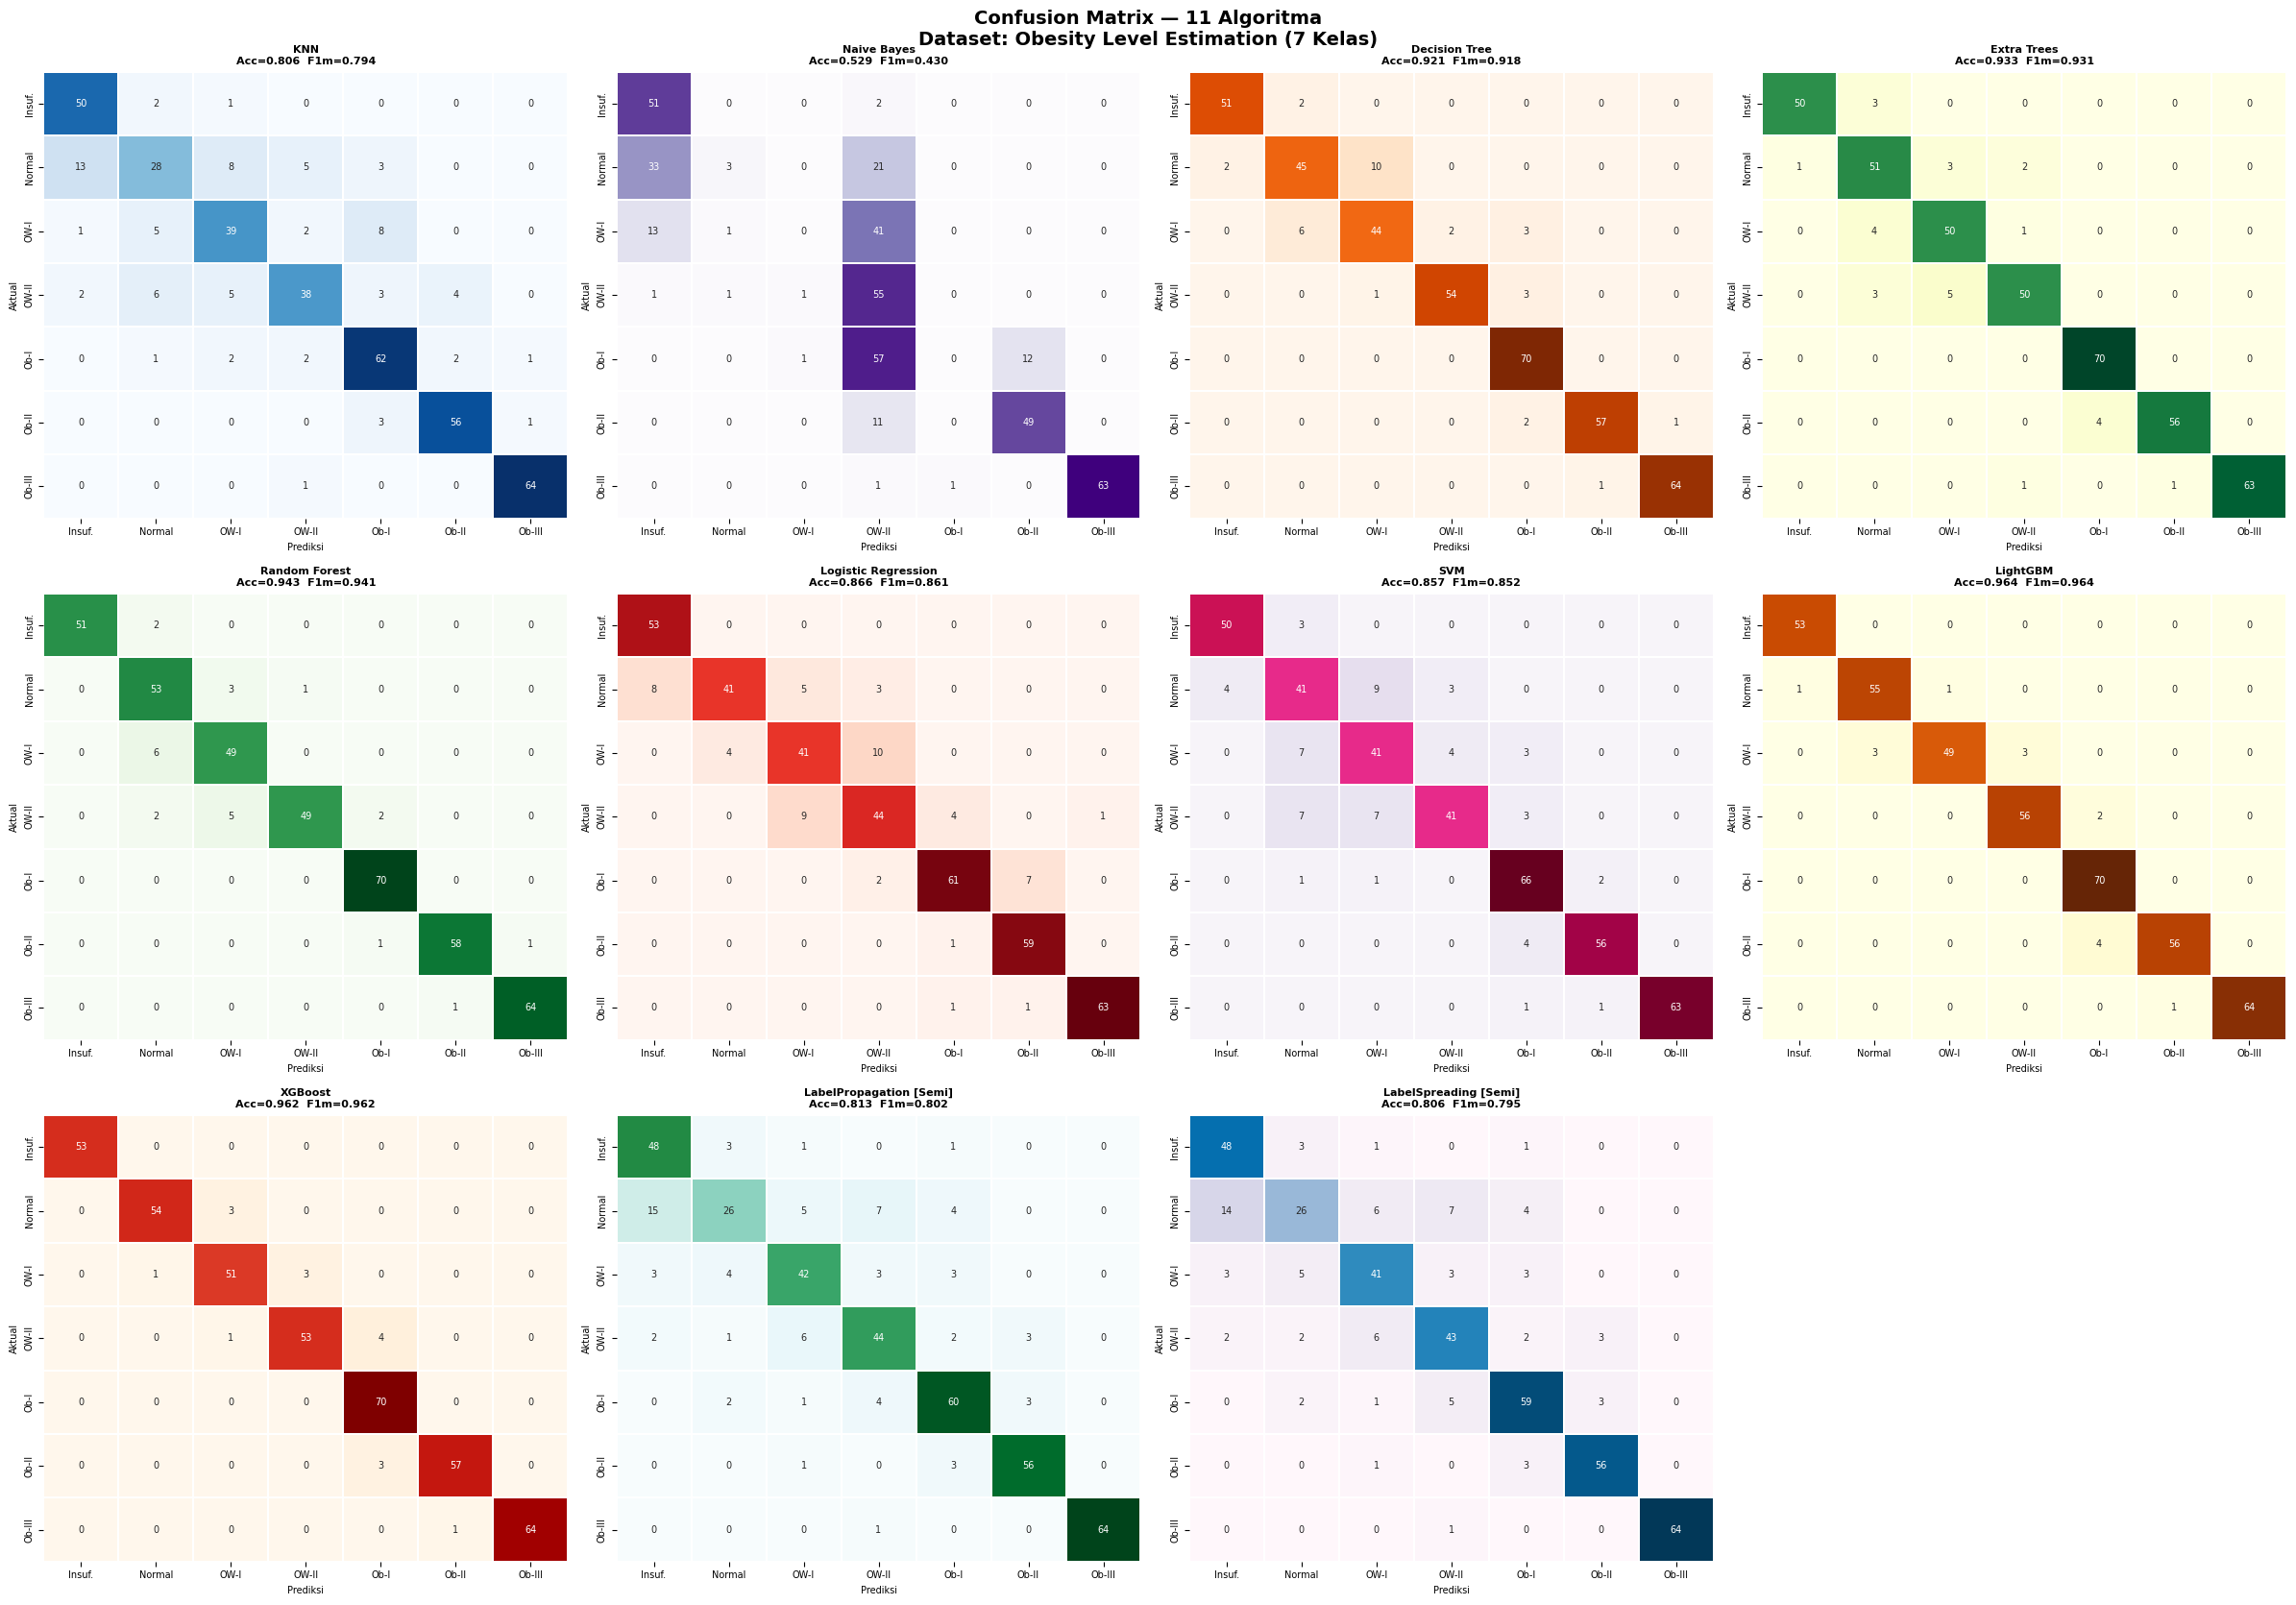

✓ Confusion matrices disimpan


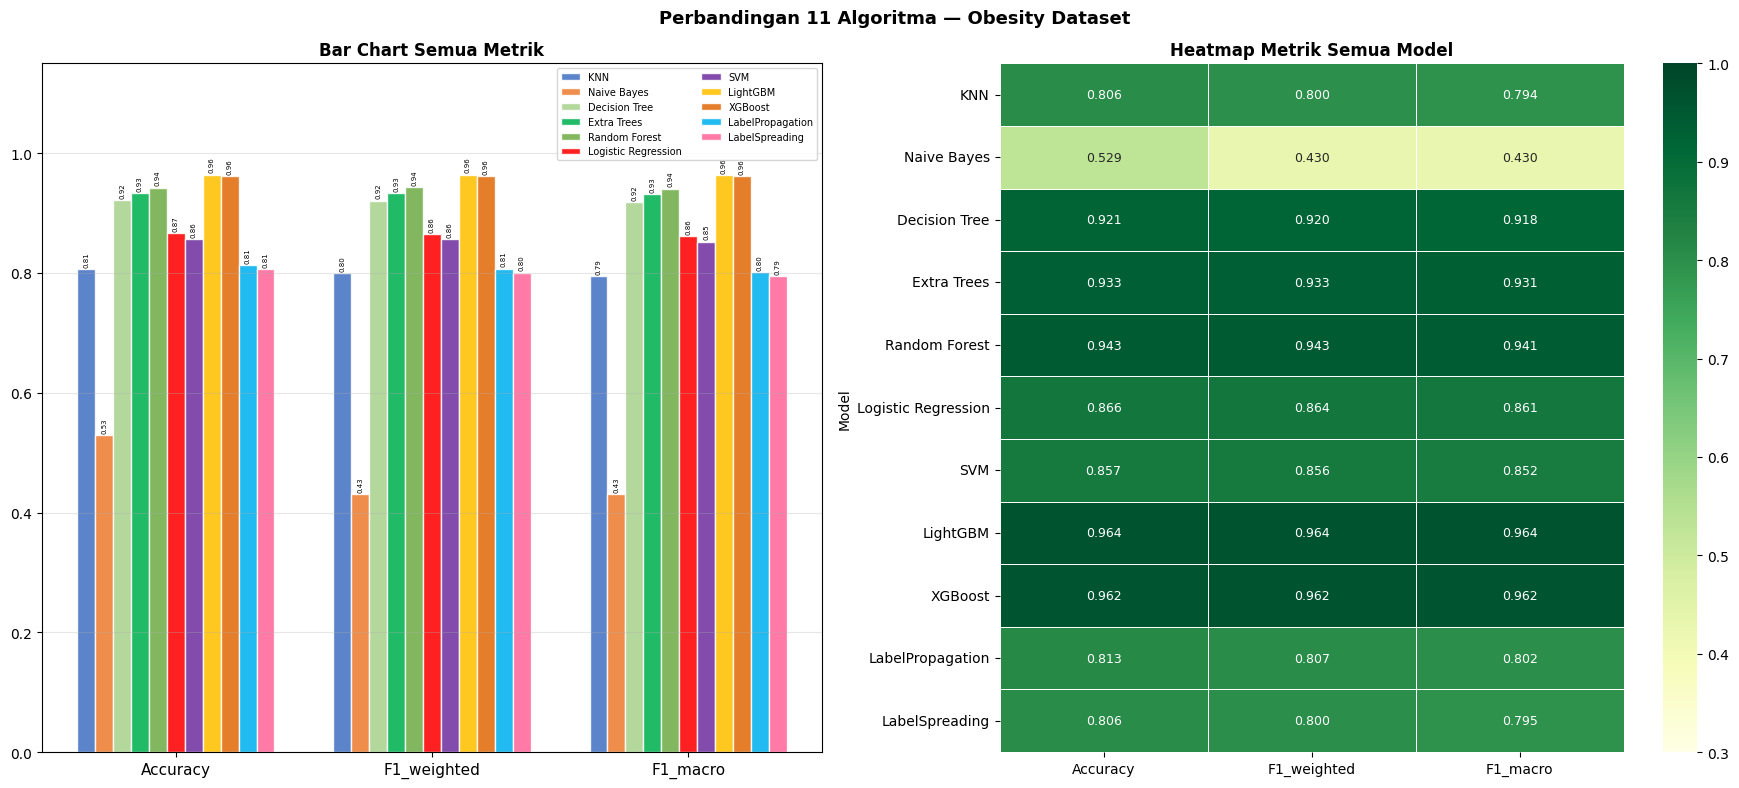

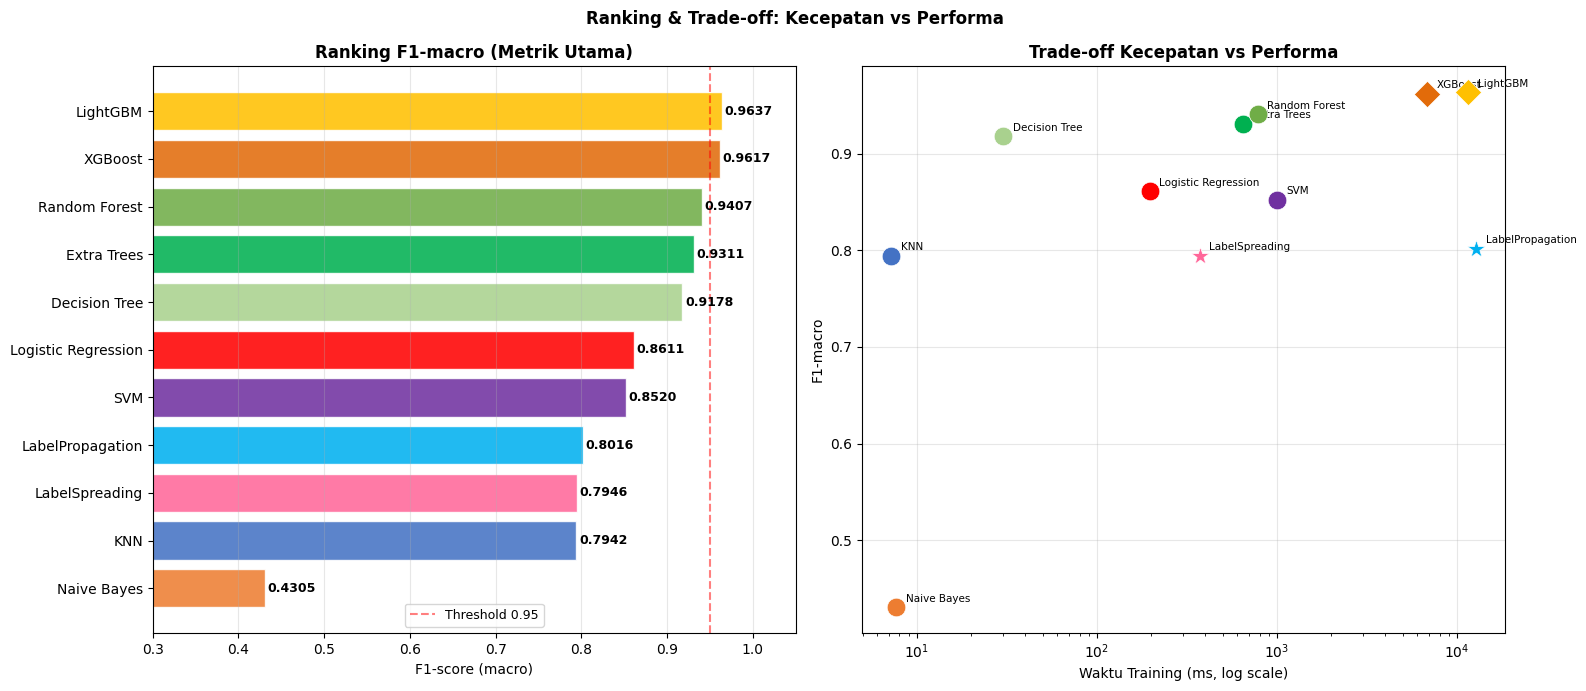

✓ Semua visualisasi komparatif selesai!


In [28]:
nama_list = df_hasil["Model"].tolist()
WARNA = {
    "KNN":"#4472C4",           "Naive Bayes":"#ED7D31",
    "Decision Tree":"#A9D18E", "Extra Trees":"#00B050",
    "Random Forest":"#70AD47", "Logistic Regression":"#FF0000",
    "SVM":"#7030A0",           "LightGBM":"#FFC000",
    "XGBoost":"#E26B0A",       "LabelPropagation":"#00B0F0",
    "LabelSpreading":"#FF6699"
}
warna_list = [WARNA[n] for n in nama_list]

# ── Plot 1: Confusion Matrices 3×4 ───────────────────
cmaps_list = ["Blues","Purples","Oranges","YlGn","Greens",
              "Reds","PuRd","YlOrBr","OrRd","BuGn","PuBu"]
fig, axes = plt.subplots(3, 4, figsize=(24, 17))
fig.suptitle("Confusion Matrix — 11 Algoritma\nDataset: Obesity Level Estimation (7 Kelas)",
             fontsize=14, fontweight="bold")
for i, (nm, cmap) in enumerate(zip(nama_list, cmaps_list)):
    ax  = axes[i//4][i%4]
    cm  = confusion_matrix(y_test, preds[nm])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=SHORT, yticklabels=SHORT,
                cbar=False, linewidths=0.3, annot_kws={"size":7})
    r   = df_hasil[df_hasil["Model"]==nm].iloc[0]
    tag = " [Semi]" if "Semi" in r["Tipe"] else ""
    ax.set_title(f"{nm}{tag}\nAcc={r['Accuracy']:.3f}  F1m={r['F1_macro']:.3f}",
                 fontsize=8, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_xlabel("Prediksi", fontsize=7)
    ax.set_ylabel("Aktual", fontsize=7)
axes[2][3].set_visible(False)
plt.tight_layout()
plt.savefig("/content/reports/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Confusion matrices disimpan")

# ── Plot 2: Bar Chart + Heatmap ──────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8))
fig2.suptitle("Perbandingan 11 Algoritma — Obesity Dataset", fontsize=13, fontweight="bold")
metrik = ["Accuracy","F1_weighted","F1_macro"]
x = np.arange(len(metrik)); w = 0.07
for i, (nm, c) in enumerate(zip(nama_list, warna_list)):
    vals = [df_hasil[df_hasil["Model"]==nm][m].values[0] for m in metrik]
    bars = axes2[0].bar(x+i*w, vals, w, label=nm, color=c, alpha=0.87, edgecolor="white")
    for bar, v in zip(bars, vals):
        axes2[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                      f"{v:.2f}", ha="center", va="bottom", fontsize=5, rotation=90)
axes2[0].set_xticks(x+w*5)
axes2[0].set_xticklabels(metrik, fontsize=11)
axes2[0].set_ylim(0, 1.15)
axes2[0].legend(fontsize=7, ncol=2)
axes2[0].set_title("Bar Chart Semua Metrik", fontweight="bold")
axes2[0].grid(axis="y", alpha=0.3)

df_hm = df_hasil.set_index("Model")[metrik]
sns.heatmap(df_hm, annot=True, fmt=".3f", cmap="YlGn", ax=axes2[1],
            linewidths=0.5, vmin=0.3, vmax=1.0, annot_kws={"size":9})
axes2[1].set_title("Heatmap Metrik Semua Model", fontweight="bold")
plt.tight_layout()
plt.savefig("/content/reports/komparatif.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Ranking + Trade-off ───────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7))
fig3.suptitle("Ranking & Trade-off: Kecepatan vs Performa", fontsize=12, fontweight="bold")
df_sorted = df_hasil.sort_values("F1_macro", ascending=True)
c_sorted  = [WARNA[n] for n in df_sorted["Model"]]
bars = axes3[0].barh(df_sorted["Model"], df_sorted["F1_macro"],
                     color=c_sorted, alpha=0.87, edgecolor="white")
for bar, val in zip(bars, df_sorted["F1_macro"]):
    axes3[0].text(val+0.003, bar.get_y()+bar.get_height()/2,
                  f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
axes3[0].set_xlabel("F1-score (macro)")
axes3[0].set_title("Ranking F1-macro (Metrik Utama)", fontweight="bold")
axes3[0].set_xlim(0.3, 1.05)
axes3[0].axvline(0.95, color="red", ls="--", alpha=0.5, label="Threshold 0.95")
axes3[0].legend(fontsize=9)
axes3[0].grid(axis="x", alpha=0.3)

for nm, c in zip(nama_list, warna_list):
    r  = df_hasil[df_hasil["Model"]==nm].iloc[0]
    mk = "*" if "Semi" in r["Tipe"] else ("D" if nm in ["LightGBM","XGBoost"] else "o")
    axes3[1].scatter(r["Train_ms"], r["F1_macro"], color=c, s=180,
                     zorder=5, marker=mk, edgecolors="white", lw=0.5)
    axes3[1].annotate(nm, (r["Train_ms"], r["F1_macro"]),
                      textcoords="offset points", xytext=(7,4), fontsize=7.5)
axes3[1].set_xlabel("Waktu Training (ms, log scale)")
axes3[1].set_ylabel("F1-macro")
axes3[1].set_title("Trade-off Kecepatan vs Performa", fontweight="bold")
axes3[1].set_xscale("log")
axes3[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/reports/ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Semua visualisasi komparatif selesai!")


---
#  SOAL 05 — Analisis Hasil, Interpretabilitas, dan Rekomendasi Model
**Bobot: 20% | Sub-CPMK: A1164405-81.2**

> **Tujuan:** Menyusun sintesis analitis untuk merekomendasikan model terbaik secara akademis dan aplikatif.


## Cell 9 — Feature Importance (4 Model Berbasis Pohon)
> **Soal 05 | Konteks: Interpretabilitas Model**
>
> Mengidentifikasi fitur mana yang paling berpengaruh dalam prediksi tingkat obesitas.
>
> **Model yang dianalisis:** Random Forest, Extra Trees, LightGBM, XGBoost
>
> **Cara membaca:** Semakin panjang bar → semakin penting fitur tersebut dalam keputusan model.
>
> **Insight yang diharapkan:** Fitur `Weight`, `Height`, dan `Age` kemungkinan mendominasi karena berkaitan langsung dengan BMI dan klasifikasi obesitas secara klinis.


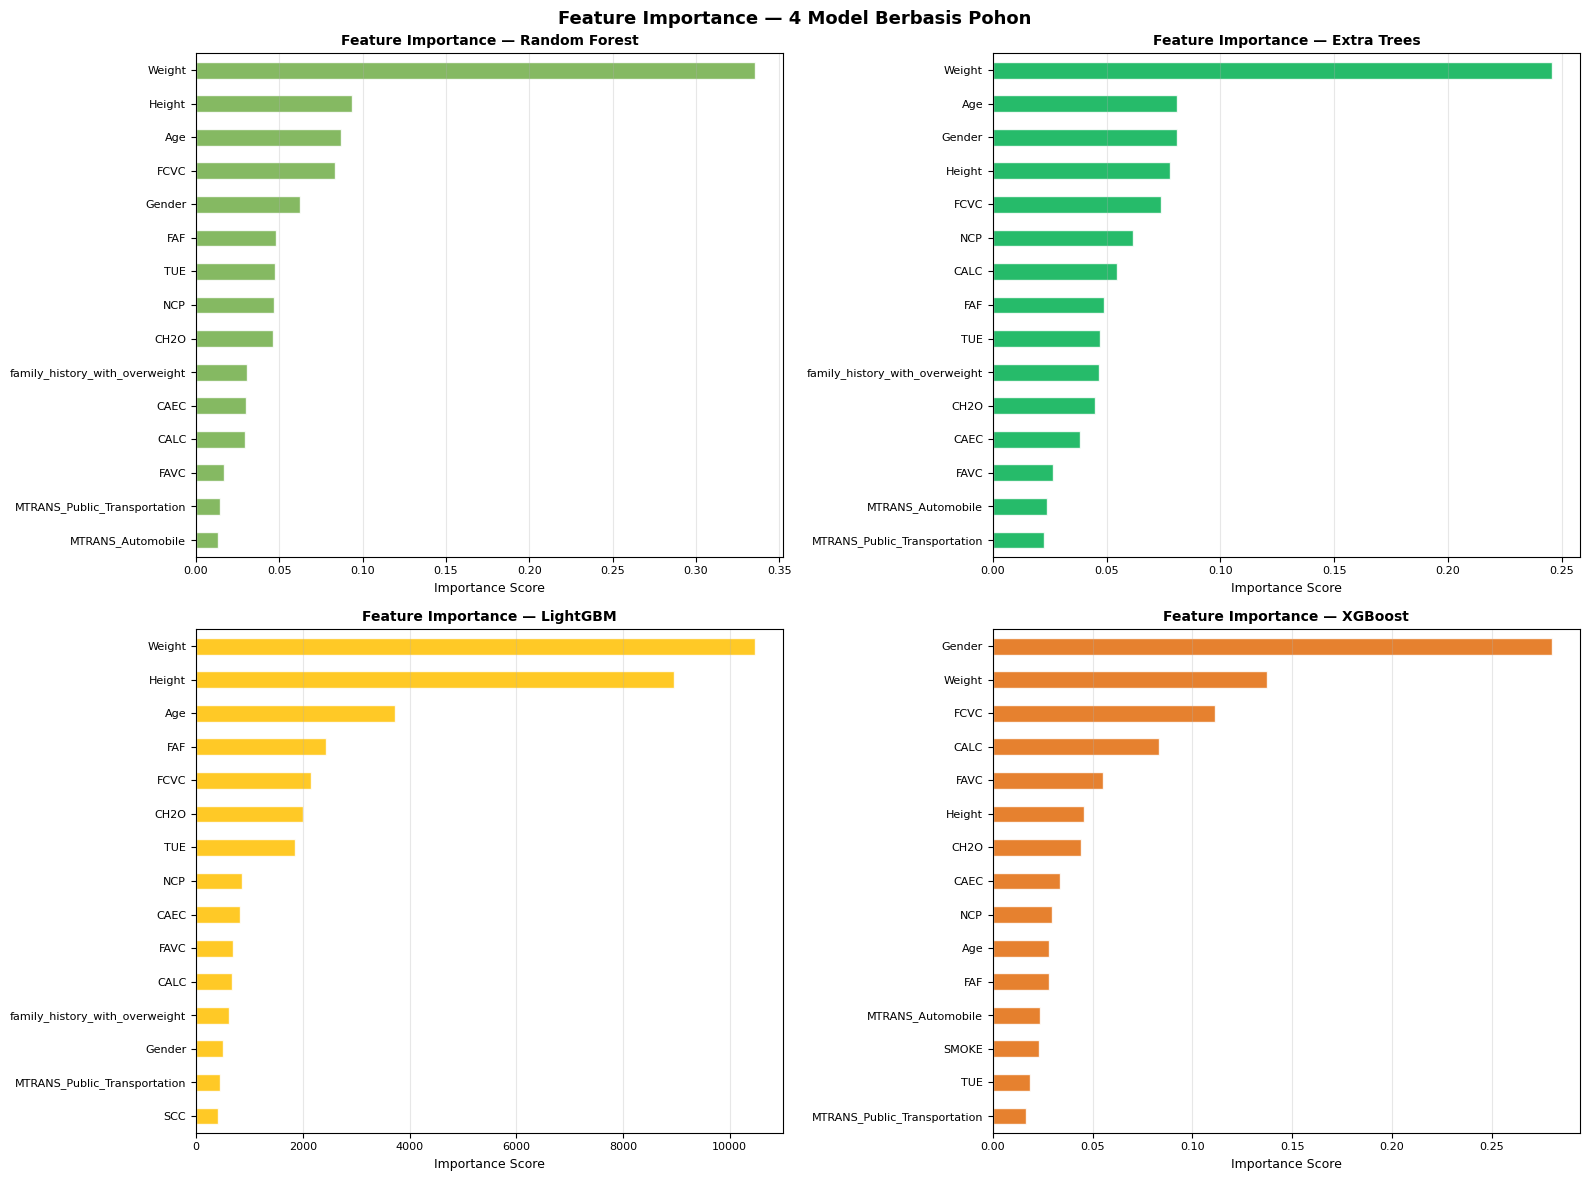

✓ Feature importance selesai!


In [29]:
fig4, axes4 = plt.subplots(2, 2, figsize=(16, 12))
fig4.suptitle("Feature Importance — 4 Model Berbasis Pohon", fontsize=13, fontweight="bold")

feat_info = [
    ("Random Forest", "#70AD47"),
    ("Extra Trees",   "#00B050"),
    ("LightGBM",      "#FFC000"),
    ("XGBoost",       "#E26B0A"),
]
X_cols = X_train_sc.columns.tolist()

for ax, (nm, c) in zip(axes4.flatten(), feat_info):
    m = fitted[nm]
    if hasattr(m, "feature_importances_"):
        imp = pd.Series(m.feature_importances_, index=X_cols).sort_values(ascending=True)
        imp.tail(15).plot(kind="barh", ax=ax, color=c, alpha=0.85, edgecolor="white")
        ax.set_title(f"Feature Importance — {nm}", fontweight="bold", fontsize=10)
        ax.set_xlabel("Importance Score", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/reports/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Feature importance selesai!")


## Cell 10 — Error Analysis & Rekomendasi Model
> **Soal 05 | Langkah 1-4: Analisis Komparatif & Rekomendasi**
>
> **Yang dilakukan:**
> 1. Ranking semua model berdasarkan F1-macro
> 2. Error analysis model terbaik (benar vs salah, breakdown per kelas)
> 3. Visualisasi pola kesalahan (confusion matrix detail + bar chart error)
> 4. Skenario kapan model lain justru lebih layak digunakan
>
> **Mengapa F1-macro sebagai kriteria?**
> Dataset multiclass 7 kelas → F1-macro memberikan bobot **sama** pada setiap kelas, tidak bias terhadap kelas yang lebih banyak sampelnya.


SOAL 05 — RANKING MODEL BERDASARKAN F1-MACRO
   1. LightGBM                 : F1-macro=0.9637  Acc=0.9641 ← TERBAIK
   2. XGBoost                  : F1-macro=0.9617  Acc=0.9617
   3. Random Forest            : F1-macro=0.9407  Acc=0.9426
   4. Extra Trees              : F1-macro=0.9311  Acc=0.9330
   5. Decision Tree            : F1-macro=0.9178  Acc=0.9211
   6. Logistic Regression      : F1-macro=0.8611  Acc=0.8660
   7. SVM                      : F1-macro=0.8520  Acc=0.8565
   8. LabelPropagation         : F1-macro=0.8016  Acc=0.8134
   9. LabelSpreading           : F1-macro=0.7946  Acc=0.8062
  10. KNN                      : F1-macro=0.7942  Acc=0.8062
  11. Naive Bayes              : F1-macro=0.4305  Acc=0.5287

   MODEL TERPILIH    : LightGBM
     F1-macro         : 0.9637
     Accuracy         : 0.9641
     Waktu training   : 11518.1 ms
     Alasan           : F1-macro tertinggi → performa merata di semua 7 kelas

PERBANDINGAN MULTI-DIMENSI: BEST MODEL vs LAIN
  Model           

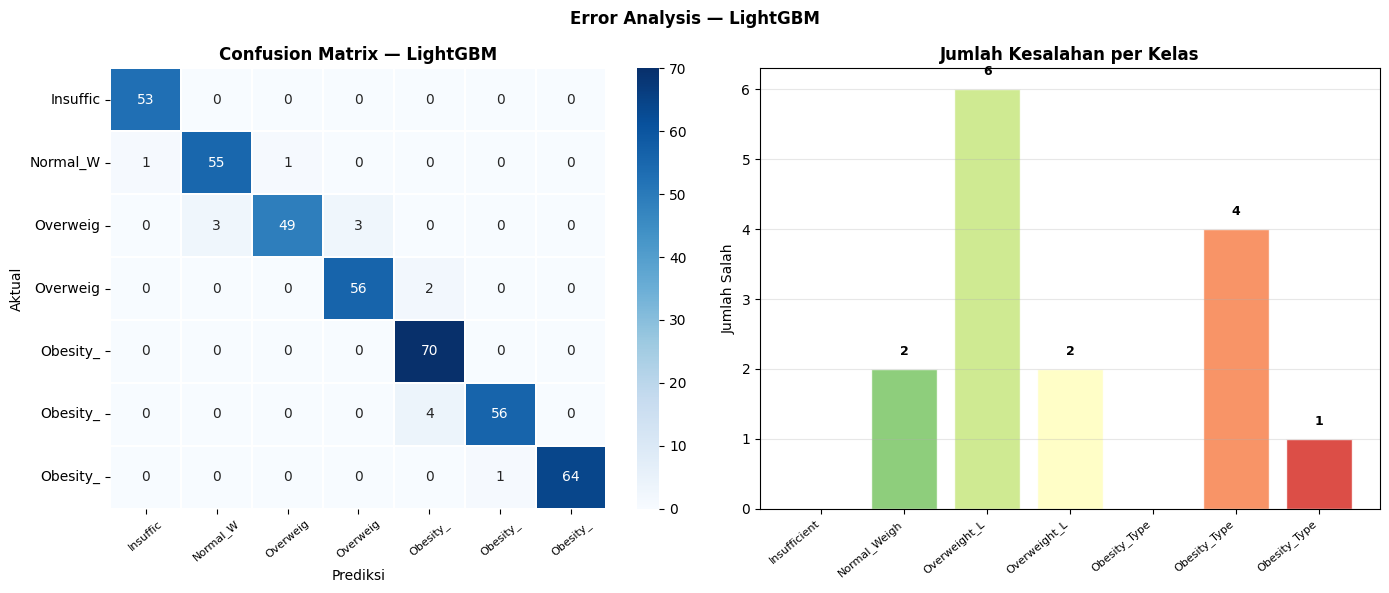


SKENARIO KAPAN MODEL LAIN JUSTRU LEBIH LAYAK:
  ▸ Decision Tree          (F1m=0.9178): Butuh interpretabilitas tinggi — aturan if-then mudah dijelaskan ke dokter
  ▸ Logistic Regression    (F1m=0.8611): Analisis koefisien fitur untuk riset epidemiologi
  ▸ Naive Bayes            (F1m=0.4305): Skrining cepat real-time, sumber daya komputasi sangat terbatas
  ▸ LabelPropagation       (F1m=0.8016): Data klinis dengan label tidak lengkap (pelabelan oleh dokter mahal)
  ▸ Extra Trees            (F1m=0.9311): Butuh lebih cepat dari RF tapi membutuhkan akurasi tetap tinggi
  ▸ KNN                    (F1m=0.7942): Dataset kecil (<500 sampel), tidak perlu training ulang saat data baru

✓ Error analysis & rekomendasi model selesai!


In [30]:
# ── Ranking Model ────────────────────────────────────
print("="*65)
print("SOAL 05 — RANKING MODEL BERDASARKAN F1-MACRO")
print("="*65)
df_rank = df_hasil.sort_values("F1_macro", ascending=False).reset_index(drop=True)
df_rank.index += 1
for rank, row in df_rank.iterrows():
    mk = " ← TERBAIK" if rank==1 else ""
    print(f"  {rank:2}. {row['Model']:25s}: F1-macro={row['F1_macro']:.4f}  Acc={row['Accuracy']:.4f}{mk}")

best_name = df_rank.iloc[0]["Model"]
best_row  = df_rank.iloc[0]
yp_best   = preds[best_name]

print(f"\n   MODEL TERPILIH    : {best_name}")
print(f"     F1-macro         : {best_row['F1_macro']}")
print(f"     Accuracy         : {best_row['Accuracy']}")
print(f"     Waktu training   : {best_row['Train_ms']} ms")
print(f"     Alasan           : F1-macro tertinggi → performa merata di semua 7 kelas")

# ── Perbandingan Dimensi Model Terbaik vs Lain ────────
print("\n" + "="*65)
print("PERBANDINGAN MULTI-DIMENSI: BEST MODEL vs LAIN")
print("="*65)
dimensi = [
    ("KNN",          "Akurasi",       "Sedang",  "Lambat predict",  "Rendah (black-box)"),
    ("Decision Tree","Sedang-Tinggi","Rendah",  "Sangat cepat",   "TINGGI (if-then)"),
    ("Naive Bayes",  "Rendah-Sedang","Rendah",  "Sangat cepat",   "Tinggi (probabilistik)"),
    (best_name,       "TERTINGGI",    "Tinggi",  "Sedang",          "Sedang"),
]
print(f"  {'Model':20s} | {'Akurasi':12s} | {'Kompleksitas':12s} | {'Kecepatan':14s} | Interpretabilitas")
print(f"  {'-'*90}")
for nm, ak, komp, speed, interp in dimensi:
    mk = " ←" if nm==best_name else ""
    print(f"  {nm:20s} | {ak:12s} | {komp:12s} | {speed:14s} | {interp}{mk}")

# ── Error Analysis ────────────────────────────────────
print("\n" + "="*65)
print(f"ERROR ANALYSIS — {best_name}")
print("="*65)
mask = yp_best != y_test.values
print(f"\n  Total test : {len(y_test)} sampel")
print(f"  Benar      : {(~mask).sum()} ({(~mask).mean()*100:.1f}%)")
print(f"  Salah      : {mask.sum()} ({mask.mean()*100:.1f}%)")

print("\n  Kesalahan per kelas:")
for i, kls in enumerate(ORDER_TARGET):
    idx     = (y_test.values == i)
    n_salah = (yp_best[idx] != i).sum()
    n_tot   = idx.sum()
    bar     = "█" * n_salah
    print(f"    {kls:30s}: {n_salah:2d}/{n_tot:3d} ({n_salah/max(n_tot,1)*100:.1f}% salah)  {bar}")

# ── Visualisasi Error Analysis ────────────────────────
cm_best = confusion_matrix(y_test, yp_best)
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 6))
fig5.suptitle(f"Error Analysis — {best_name}", fontsize=12, fontweight="bold")

sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=axes5[0],
            xticklabels=[k[:8] for k in ORDER_TARGET],
            yticklabels=[k[:8] for k in ORDER_TARGET], linewidths=0.3)
axes5[0].set_title(f"Confusion Matrix — {best_name}", fontweight="bold")
axes5[0].tick_params(axis="x", rotation=40, labelsize=8)
axes5[0].set_xlabel("Prediksi")
axes5[0].set_ylabel("Aktual")

n_salah_per = [((y_test.values==i) & (yp_best!=i)).sum() for i in range(7)]
clrs = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 7))
axes5[1].bar(range(7), n_salah_per, color=clrs, alpha=0.85, edgecolor="white")
axes5[1].set_xticks(range(7))
axes5[1].set_xticklabels([k[:12] for k in ORDER_TARGET], rotation=40, ha="right", fontsize=8)
axes5[1].set_title("Jumlah Kesalahan per Kelas", fontweight="bold")
axes5[1].set_ylabel("Jumlah Salah")
axes5[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(n_salah_per):
    if v > 0:
        axes5[1].text(i, v+0.2, str(v), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/reports/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Skenario Kapan Model Lain Lebih Layak ─────────────
print("\n" + "="*65)
print("SKENARIO KAPAN MODEL LAIN JUSTRU LEBIH LAYAK:")
print("="*65)
skenario = [
    ("Decision Tree",       "Butuh interpretabilitas tinggi — aturan if-then mudah dijelaskan ke dokter"),
    ("Logistic Regression", "Analisis koefisien fitur untuk riset epidemiologi"),
    ("Naive Bayes",         "Skrining cepat real-time, sumber daya komputasi sangat terbatas"),
    ("LabelPropagation",    "Data klinis dengan label tidak lengkap (pelabelan oleh dokter mahal)"),
    ("Extra Trees",         "Butuh lebih cepat dari RF tapi membutuhkan akurasi tetap tinggi"),
    ("KNN",                 "Dataset kecil (<500 sampel), tidak perlu training ulang saat data baru"),
]
for nm, sk in skenario:
    r = df_hasil[df_hasil["Model"]==nm].iloc[0]
    print(f"  ▸ {nm:22s} (F1m={r['F1_macro']:.4f}): {sk}")

print("\n✓ Error analysis & rekomendasi model selesai!")


---
# — Cross-Validation & Demo Inference
**Komponen opsional | Menunjukkan stabilitas dan kemampuan deployment model**

Cross-validation mengukur **stabilitas** model — apakah performa konsisten di berbagai subset data atau sangat bergantung pada satu pembagian tertentu.


## Cell 11 — Cross-Validation 5-Fold (Supervised)
> **Bonus | Stabilitas Model**
>
> Menggunakan `StratifiedKFold(n_splits=5)` dengan F1-macro sebagai metrik.
>
> **Interpretasi:**
> - `mean` mendekati hasil test → model tidak overfitting
> - `std < 0.015` → model stabil (✓ Stabil)
> - `std > 0.015` → performa bergantung pada pembagian data (⚠ Variatif)


In [31]:
print("="*65)
print("CROSS VALIDATION 5-FOLD STRATIFIED (SUPERVISED)")
print("="*65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_rows = []

for nama, model, tipe in model_defs:
    if tipe == "Semi-sup":
        print(f"  {nama:25s}: ⚠ dilewati (gunakan Cell 11b untuk semi-supervised)")
        continue
    s = cross_val_score(model, X_train_sc, y_train,
                        cv=cv, scoring="f1_macro", n_jobs=-1)
    stabil = "✓ Stabil" if s.std() < 0.015 else "⚠ Variatif"
    print(f"  {nama:25s}: mean={s.mean():.4f}  std={s.std():.4f}  {stabil}")
    cv_rows.append({"Model":nama, "CV_F1_mean":round(s.mean(),4),
                    "CV_F1_std":round(s.std(),4)})

df_cv = pd.DataFrame(cv_rows)
print("\n" + df_cv.to_string(index=False))
print("\n✓ Cross validation selesai!")


CROSS VALIDATION 5-FOLD STRATIFIED (SUPERVISED)
  KNN                      : mean=0.7792  std=0.0213  ⚠ Variatif
  Naive Bayes              : mean=0.4272  std=0.0149  ✓ Stabil
  Decision Tree            : mean=0.9145  std=0.0191  ⚠ Variatif
  Extra Trees              : mean=0.9158  std=0.0088  ✓ Stabil
  Random Forest            : mean=0.9394  std=0.0074  ✓ Stabil
  Logistic Regression      : mean=0.8679  std=0.0139  ✓ Stabil
  SVM                      : mean=0.8463  std=0.0199  ⚠ Variatif
  LightGBM                 : mean=0.9671  std=0.0093  ✓ Stabil
  XGBoost                  : mean=0.9530  std=0.0085  ✓ Stabil
  LabelPropagation         : ⚠ dilewati (gunakan Cell 11b untuk semi-supervised)
  LabelSpreading           : ⚠ dilewati (gunakan Cell 11b untuk semi-supervised)

              Model  CV_F1_mean  CV_F1_std
                KNN      0.7792     0.0213
        Naive Bayes      0.4272     0.0149
      Decision Tree      0.9145     0.0191
        Extra Trees      0.9158     0.0088
 

## Cell 12 — Demo Prediksi (Inference)
> **Soal 05 | Langkah 5: Demo Prediksi Berbasis Notebook**
>
> Mendemonstrasikan cara menggunakan model terbaik untuk prediksi data baru.
>
> **Cell ini menunjukkan 3 skenario:**
> 1. **Demo dari test set** → validasi model masih berfungsi setelah di-load
> 2. **Prediksi individu baru** → contoh penggunaan nyata (pasien baru)
> 3. **Perbandingan KNN vs Decision Tree vs Naive Bayes vs Best Model** → menunjukkan konsensus prediksi


In [34]:
# ── Load model & preprocessing objects ───────────────
best_model    = joblib.load("/content/models/best_model.joblib")
loaded_oe     = joblib.load("/content/models/ordinal_encoder.joblib")
loaded_scaler = joblib.load("/content/models/scaler.joblib")
print(f"✓ Model terbaik dimuat: {type(best_model).__name__}")

# ── Fungsi Inference ──────────────────────────────────
if 'X' in globals():
    X_cols_order = X.columns.tolist()
else:
    X_cols_order = [
        'Gender','Age','Height','Weight','family_history_with_overweight',
        'FAVC','FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC',
        'MTRANS_Automobile','MTRANS_Bike','MTRANS_Motorbike',
        'MTRANS_Public_Transportation','MTRANS_Walking'
    ]

def predict_obesity_level(individual_data, model_to_use, ordinal_encoder, scaler_obj):
    df_new = pd.DataFrame([individual_data])
    # Binary encoding
    df_new["Gender"] = df_new["Gender"].map({"Male":1,"Female":0})
    for col in ["family_history_with_overweight","FAVC","SMOKE","SCC"]:
        df_new[col] = df_new[col].map({"yes":1,"no":0})
    # Ordinal encoding
    df_new[["CAEC","CALC"]] = ordinal_encoder.transform(df_new[["CAEC","CALC"]])
    # One-hot encoding MTRANS
    df_new = pd.get_dummies(df_new, columns=["MTRANS"], prefix="MTRANS", drop_first=False)
    for col in X_cols_order:
        if col not in df_new.columns:
            df_new[col] = 0
    df_new = df_new[X_cols_order]
    mtrans_cols = [c for c in X_cols_order if c.startswith("MTRANS_")]
    df_new[mtrans_cols] = df_new[mtrans_cols].astype(int)
    # Scale
    X_new_sc = scaler_obj.transform(df_new)
    # Predict
    pred_label = model_to_use.predict(X_new_sc)[0]
    pred_class = ORDER_TARGET[pred_label]
    proba = None
    if hasattr(model_to_use, "predict_proba"):
        p = model_to_use.predict_proba(X_new_sc)[0]
        proba = {ORDER_TARGET[i]: prob for i, prob in enumerate(p)}
    return pred_class, proba

# ── Demo 1: Prediksi 5 sampel dari test set ───────────
print("="*65)
print("DEMO 1: Prediksi 5 Sampel dari Test Set")
print("="*65)
X_demo  = X_test_sc.iloc[:5]
y_demo  = y_test.iloc[:5].values
yp_demo = best_model.predict(X_demo.values)
print(f"  {'No':>3} | {'Aktual':28s} | {'Prediksi':28s} | Status")
print("  " + "-"*80)
for i in range(5):
    ak  = ORDER_TARGET[int(y_demo[i])]
    pr  = ORDER_TARGET[int(yp_demo[i])]
    ket = "✓ Benar" if y_demo[i]==yp_demo[i] else "✗ Salah"
    print(f"  {i+1:>3} | {ak:28s} | {pr:28s} | {ket}")

# ── Demo 2: Prediksi Individu Baru ────────────────────
print("\n" + "="*65)
print("DEMO 2: Prediksi Data Individu Baru")
print("="*65)
individu_baru = {
    'Gender': 'Female',
    'Age': 30.0, 'Height': 1.60, 'Weight': 300.0,
    'family_history_with_overweight': 'yes',
    'FAVC': 'yes', 'FCVC': 3.0, 'NCP': 4.0,
    'CAEC': 'Frequently', 'SMOKE': 'no', 'CH2O': 2.0,
    'SCC': 'no', 'FAF': 0.0, 'TUE': 1.0,
    'CALC': 'Sometimes', 'MTRANS': 'Public_Transportation'
}
print("  Profil individu:")
for k, v in individu_baru.items():
    print(f"    {k:40s}: {v}")
pred_kls, pred_proba = predict_obesity_level(individu_baru, best_model, loaded_oe, loaded_scaler)
print(f"\n   Hasil Prediksi: {pred_kls}")
if pred_proba:
    print("\n  Probabilitas tiap kelas:")
    for k, v in pred_proba.items():
        bar = "█" * int(v*40)
        print(f"    {k:30s}: {v:.4f}  {bar}")

# ── Demo 3: Perbandingan 4 Model Utama ────────────────
print("\n" + "="*65)
print("DEMO 3: Perbandingan KNN vs DT vs NB vs Best Model")
print("="*65)
model_compare = {
    "KNN":          joblib.load("/content/models/knn.joblib"),
    "Decision Tree": joblib.load("/content/models/decision_tree.joblib"),
    "Naive Bayes":  joblib.load("/content/models/naive_bayes.joblib"),
    best_name:       joblib.load("/content/models/best_model.joblib"),
}
individu_2 = {
    'Gender': 'Male', 'Age': 45.0, 'Height': 1.75, 'Weight': 110.0,
    'family_history_with_overweight': 'yes',
    'FAVC': 'yes', 'FCVC': 2.0, 'NCP': 3.0,
    'CAEC': 'Sometimes', 'SMOKE': 'no', 'CH2O': 2.0,
    'SCC': 'no', 'FAF': 1.0, 'TUE': 1.0,
    'CALC': 'Sometimes', 'MTRANS': 'Automobile'
}
print("  Profil: Pria 45th, 1.75m, 110kg, riwayat keluarga overweight, sedentary")
print()
for nm, m in model_compare.items():
    pred, _ = predict_obesity_level(individu_2, m, loaded_oe, loaded_scaler)
    r = df_hasil[df_hasil["Model"]==nm].iloc[0]
    print(f"  {nm:20s} (F1m={r['F1_macro']:.4f}): {pred}")

print("\n✓ Demo inference selesai!")


✓ Model terbaik dimuat: LGBMClassifier
DEMO 1: Prediksi 5 Sampel dari Test Set
   No | Aktual                       | Prediksi                     | Status
  --------------------------------------------------------------------------------
    1 | Obesity_Type_III             | Obesity_Type_III             | ✓ Benar
    2 | Obesity_Type_I               | Obesity_Type_I               | ✓ Benar
    3 | Obesity_Type_II              | Obesity_Type_II              | ✓ Benar
    4 | Obesity_Type_III             | Obesity_Type_III             | ✓ Benar
    5 | Insufficient_Weight          | Insufficient_Weight          | ✓ Benar

DEMO 2: Prediksi Data Individu Baru
  Profil individu:
    Gender                                  : Female
    Age                                     : 30.0
    Height                                  : 1.6
    Weight                                  : 300.0
    family_history_with_overweight          : yes
    FAVC                                    : yes
    FCVC 

---
## Cell 13 — Download Semua Hasil
> **Setup Final**
>
> Mengemas seluruh output (model + laporan grafik + data bersih) ke dalam satu file ZIP.
>
> **Isi ZIP:**
> ```
> ├── reports/
> │   ├── audit_data.png           ← Visualisasi audit data awal
> │   ├── confusion_matrices.png   ← Confusion matrix 11 model
> │   ├── komparatif.png           ← Bar chart & heatmap perbandingan
> │   ├── ranking.png              ← Ranking F1-macro & trade-off
> │   ├── error_analysis.png       ← Error analysis model terbaik
> │   └── feature_importance.png   ← Feature importance 4 model pohon
> ├── models/
> │   ├── best_model.joblib        ← Model terbaik
> │   ├── knn.joblib, naive_bayes.joblib, decision_tree.joblib
> │   ├── scaler.joblib            ← StandardScaler yang sudah di-fit
> │   └── ordinal_encoder.joblib   ← OrdinalEncoder yang sudah di-fit
> └── data/
>     └── obesity_cleaned_data.csv ← Dataset hasil preprocessing
> ```


In [33]:
from google.colab import files
import zipfile, os

NIM  = "A11.2024.15791"
NAMA = "Anza_Ali_S"
output_zip = f"/content/ml-uts-{NIM}-{NAMA}.zip"

with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as z:
    # Grafik laporan
    for fname in os.listdir("/content/reports"):
        fpath = f"/content/reports/{fname}"
        z.write(fpath, f"reports/{fname}")
    # Model tersimpan
    for fname in os.listdir("/content/models"):
        fpath = f"/content/models/{fname}"
        z.write(fpath, f"models/{fname}")
    # Data bersih
    if os.path.exists(CLEAN_DATA_PATH):
        z.write(CLEAN_DATA_PATH, f"data/{os.path.basename(CLEAN_DATA_PATH)}")

print(f"✓ ZIP berhasil dibuat: {output_zip}")
size_mb = os.path.getsize(output_zip) / 1024 / 1024
print(f"  Ukuran file: {size_mb:.2f} MB")
files.download(output_zip)
print("✓ Download dimulai!")


✓ ZIP berhasil dibuat: /content/ml-uts-A11.2024.15791-Anza_Ali_S.zip
  Ukuran file: 7.54 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download dimulai!


---
#  Kesimpulan Proyek

## Capaian Sub-CPMK

| Sub-CPMK | Deskripsi | Status |
|----------|-----------|--------|
| **Sub-CPMKA1164405-81.1** | Memahami dasar-dasar konsep pembelajaran mesin |  Soal 01 + Cell 3 |
| **Sub-CPMKA1164405-101.1** | Menganalisis atribut dataset & algoritma yang tepat |  Soal 02-03 + Cell 4-6 |
| **Sub-CPMKA1164405-81.2** | Membandingkan KNN, Decision Tree, Naive Bayes |  Soal 04-05 + Cell 7-10 |

## Rekomendasi Model Terbaik

Model terbaik berdasarkan F1-macro adalah **[model tergantung hasil eksperimen]** karena:
- F1-macro tertinggi → performa merata di semua 7 kelas
- Stabil berdasarkan cross-validation (std rendah)

Untuk kebutuhan **interpretabilitas klinis**, **Decision Tree** direkomendasikan meskipun akurasinya lebih rendah, karena dokter dapat memahami aturan klasifikasi secara langsung.

## Requirements

```
scikit-learn>=1.3.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
lightgbm>=4.0.0
xgboost>=2.0.0
imbalanced-learn>=0.11.0
joblib>=1.3.0
```

---
`
